# Exploratory analysis of how inequalities are reflected in Olympic Games over time

#### Short Notes

- The dataset goes from **1896 to 2016**
- This notebook studies how inequalities appear in Olympic history through three main angles:

1. **Gender inequalities**  
2. **Geopolitical inequalities and disruptions**  
3. **Evolution of disciplines and structural inequalities**  

In [244]:
%matplotlib inline

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.express as px
import plotly.io as pio

sns.set_theme(style="whitegrid", context="talk")
pio.templates.default = "plotly_white"

plt.rcParams.update({
    "figure.figsize": (13, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.titlesize": 18,
    "legend.frameon": False,
})

PALETTES = {
    "main": sns.color_palette("viridis", 8),
    "warm": sns.color_palette("magma", 8),
    "cool": sns.color_palette("crest", 8),
    "gender": {"F": "#d14988", "M": "#2f6690", "Women": "#d14988", "Men": "#2f6690"},
    "medals": {"Gold": "#D4AF37", "Silver": "#9AA0A6", "Bronze": "#B87333"},
    "conflict": {True: "#c1121f", False: "#669bbc"},
}


def polish_axes(ax, title, subtitle=None, xlabel=None, ylabel=None):
    ax.set_title(title, loc="left", pad=16)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=11, color="#555555")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    return ax


## 1 Dataset Preprocessing

Datasets were merged and cleaned in [merge_datasets.ipynb](merge_datasets.ipynb)

### 1.1 Dataset overview

In [245]:
olympics = pd.read_csv("../../data/olympics.csv")
print("Entries in Olympics Dataset:", olympics.shape[0])
print("Olympics Dataset Columns:", ", ".join(olympics.columns))
print("Years:", olympics["year"].min(), "-", olympics["year"].max())
print("Countries:", olympics["country"].nunique())
print("Sports:", olympics["sport"].nunique())
print("Events:", olympics["event"].nunique())
print("Athlete records:", len(olympics))

Entries in Olympics Dataset: 271116
Olympics Dataset Columns: id, name, gender, age, height, weight, team, noc, country, population, year, season, city, sport, event, medal, gdp_per_capita, conflict_name, conflict_start, conflict_end, conflict_reason, conflict_result
Years: 1896 - 2016
Countries: 205
Sports: 66
Events: 765
Athlete records: 271116


## 2 Participation Analysis

### 2.1 Participation over time

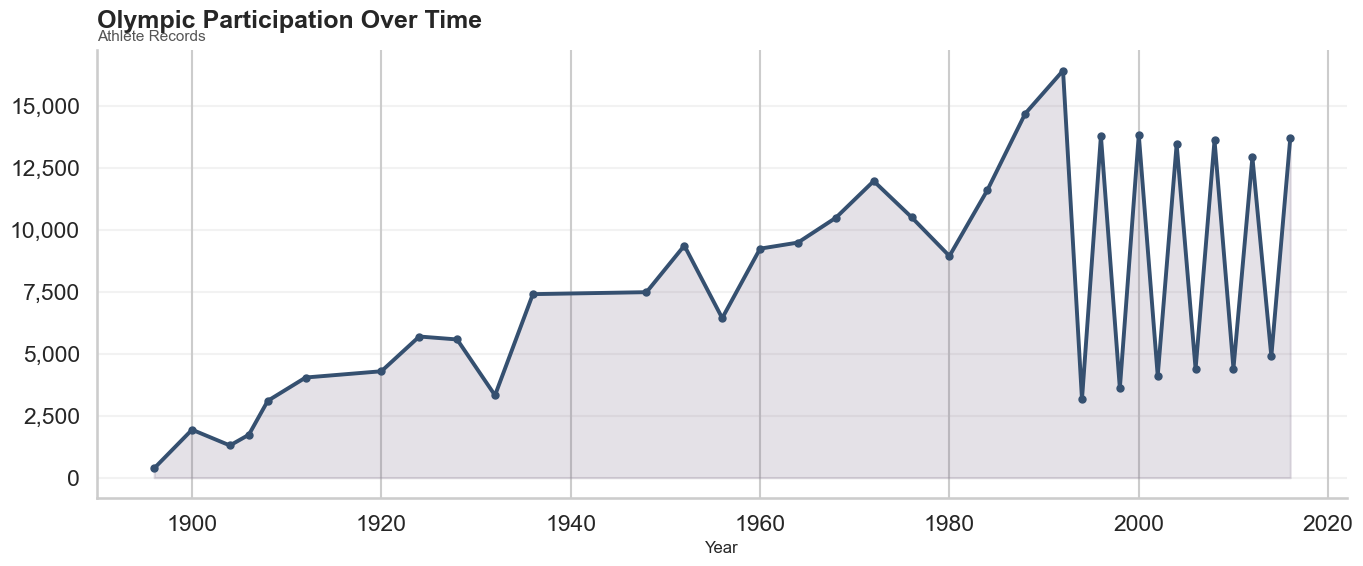

In [246]:
athletes_per_year = olympics.groupby("year").size().reset_index(name="athletes")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    athletes_per_year["year"],
    athletes_per_year["athletes"],
    color="#355070",
    linewidth=2.8,
    marker="o",
    markersize=5,
)
ax.fill_between(
    athletes_per_year["year"],
    athletes_per_year["athletes"],
    color="#6d597a",
    alpha=0.18,
)
polish_axes(
    ax,
    "Olympic Participation Over Time",
    "Athlete Records",
    "Year",
)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()


### 2.2 Participating countries 

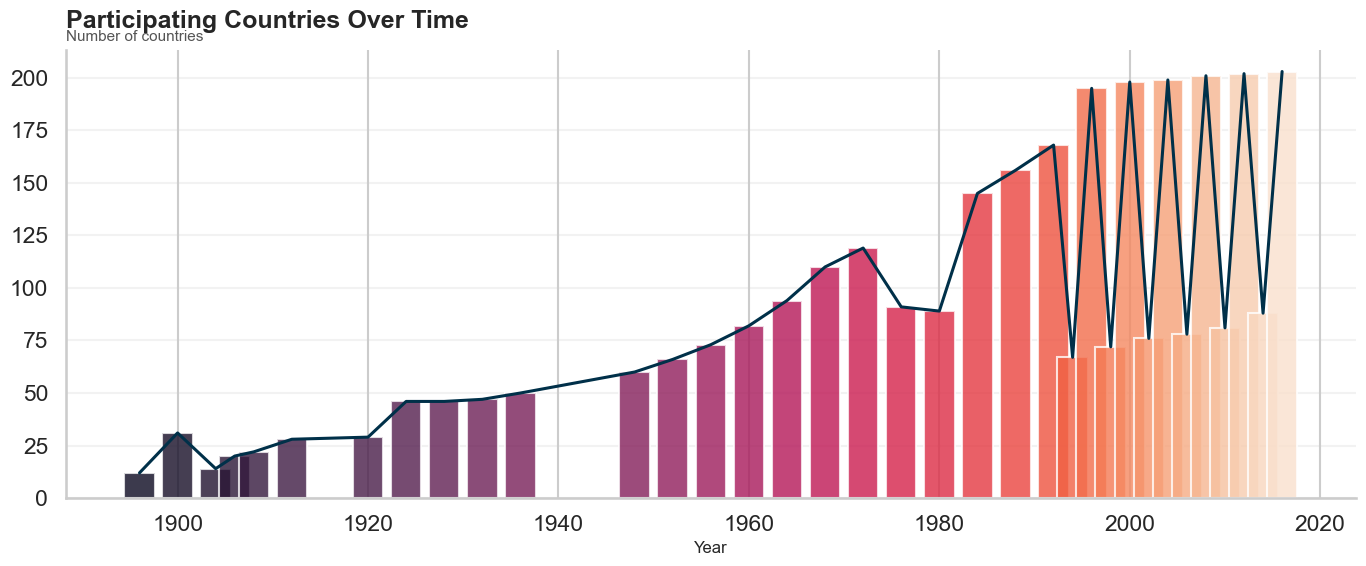

In [247]:
countries_per_year = olympics.groupby("year")["country"].nunique().reset_index(name="countries")

fig, ax = plt.subplots(figsize=(14, 6))
bar_colors = sns.color_palette("rocket", len(countries_per_year))
ax.bar(countries_per_year["year"], countries_per_year["countries"], color=bar_colors, alpha=0.8, width=3.2)
ax.plot(countries_per_year["year"], countries_per_year["countries"], color="#003049", linewidth=2.2)
polish_axes(
    ax,
    "Participating Countries Over Time",
    "Number of countries",
    "Year",
)
plt.tight_layout()
plt.show()


## 3 Gender Representation

### 3.1 Female participation share

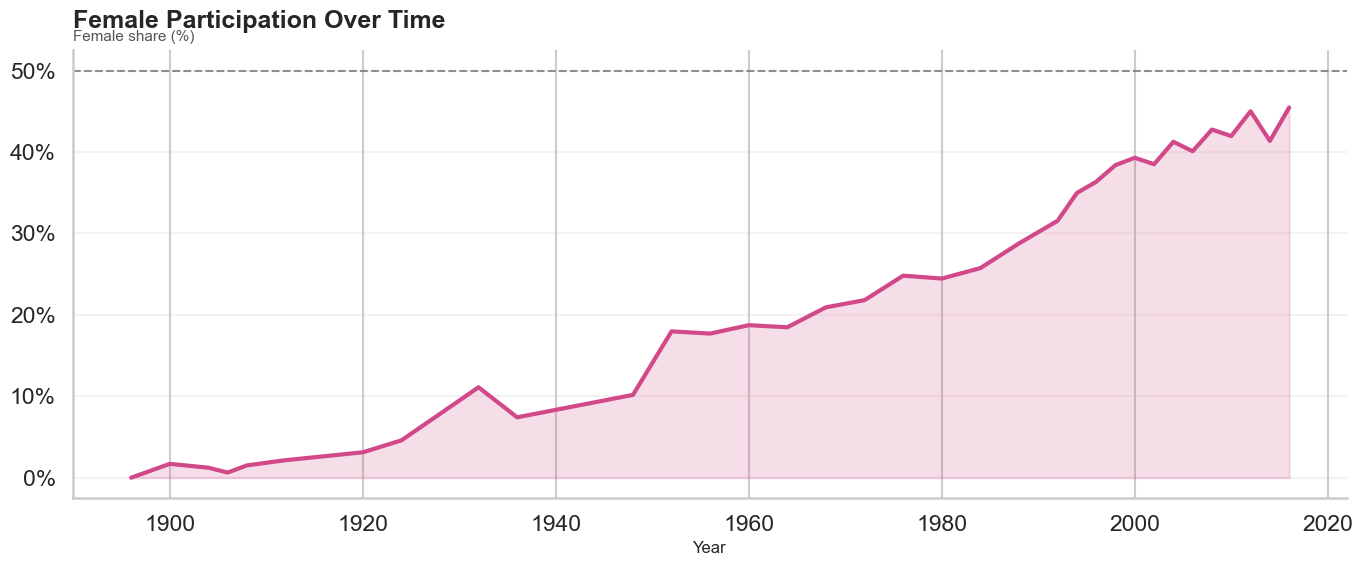

In [248]:
gender = olympics.groupby(["year","gender"]).size().unstack(fill_value=0)

gender["total"] = gender.sum(axis=1)
gender["female_share"] = 100 * gender["F"] / gender["total"]

gender = gender.reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(gender["year"], gender["female_share"], color=PALETTES["gender"]["F"], linewidth=3)
ax.fill_between(gender["year"], gender["female_share"], color=PALETTES["gender"]["F"], alpha=0.18)
ax.axhline(50, linestyle="--", linewidth=1.5, color="#6c757d", alpha=0.8)
polish_axes(
    ax,
    "Female Participation Over Time",
    "Female share (%)",
    "Year",
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()


### 3.2 Male vs female participation

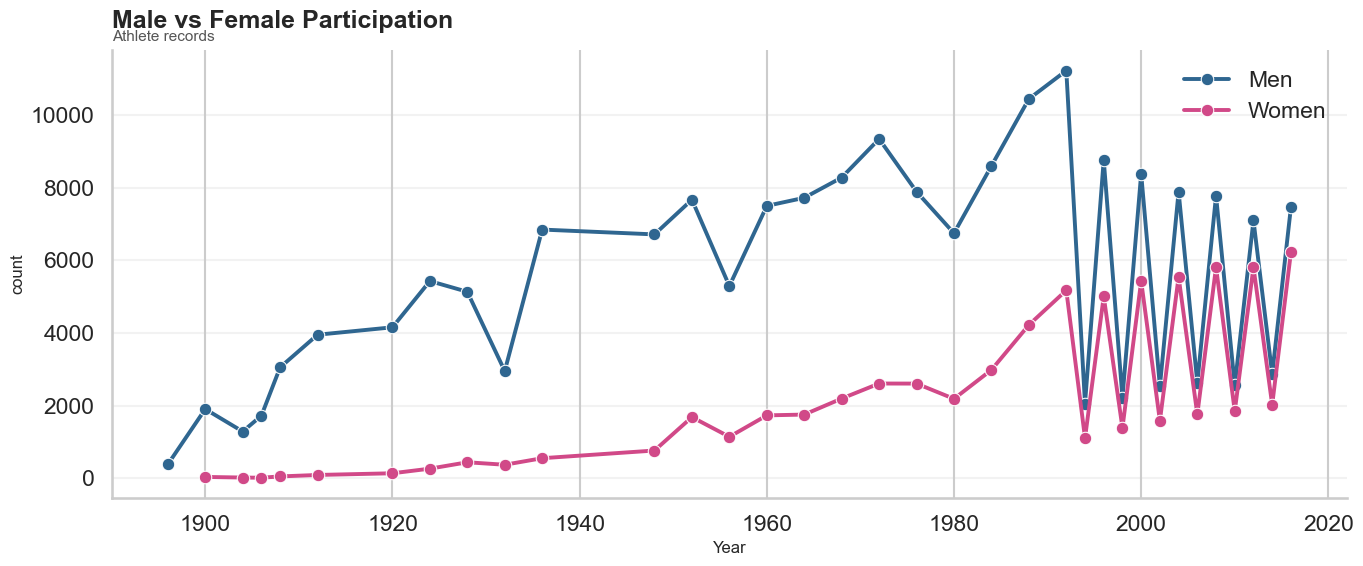

In [249]:
gender_counts = olympics.groupby(["year","gender"]).size().reset_index(name="count")
gender_counts["gender_label"] = gender_counts["gender"].map({"M": "Men", "F": "Women"})

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=gender_counts,
    x="year",
    y="count",
    hue="gender_label",
    palette={"Men": PALETTES["gender"]["Men"], "Women": PALETTES["gender"]["Women"]},
    linewidth=2.8,
    marker="o",
    ax=ax,
)
polish_axes(
    ax,
    "Male vs Female Participation",
    "Athlete records",
    "Year",
)
ax.legend(title="")
plt.tight_layout()
plt.show()


In [250]:
gender_time = olympics.groupby(["year", "gender"]).size().reset_index(name="count")

gender_time["gender"] = gender_time["gender"].replace({"M": "Men", "F": "Women"})

all_years = sorted(gender_time["year"].unique())
all_genders = ["Men", "Women"]

full_index = pd.MultiIndex.from_product(
    [all_years, all_genders],
    names=["year", "gender"]
)

gender_time = (
    gender_time
    .set_index(["year", "gender"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

fig_gender = px.bar(
    gender_time,
    x="gender",
    y="count",
    color="gender",
    animation_frame="year",
    range_y=[0, gender_time["count"].max() + 500],
    title="The Path to Parity: Athlete Records Over Time by Gender",
    template="ggplot2",
    color_discrete_map={
        "Men": "#ADD8E6",
        "Women": "#FFB6C1"
    }
)

fig_gender.update_layout(
    xaxis_title="Gender",
    yaxis_title="Number of Athlete Records"
)

fig_gender.show()

In [251]:
gender_share = (
    olympics.groupby(["year", "gender"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"F": "Women", "M": "Men"})
)

gender_share["total"] = gender_share.sum(axis=1)
gender_share["women_share"] = 100 * gender_share["Women"] / gender_share["total"]

print("Women's Share of Athlete Records by Year:")
gender_share[["Women", "Men", "women_share"]].tail(10)

Women's Share of Athlete Records by Year:


gender,Women,Men,women_share
year,,,
1998,1384,2221,38.391123
2000,5431,8390,39.295275
2002,1582,2527,38.500852
2004,5546,7897,41.255672
2006,1757,2625,40.095847
2008,5816,7786,42.758418
2010,1847,2555,41.958201
2012,5815,7105,45.007740
2014,2023,2868,41.361685


In [252]:
sport_gender = (
    olympics.groupby(["sport", "gender"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"F": "Women", "M": "Men"})
)

sport_gender["total"] = sport_gender.sum(axis=1)
sport_gender["women_share"] = 100 * sport_gender["Women"] / sport_gender["total"]

sport_gender.sort_values("women_share").head(10)

gender,Women,Men,total,women_share
sport,,,,
Aeronautics,0,1,1,0.0
Baseball,0,894,894,0.0
Cricket,0,24,24,0.0
Basque Pelota,0,2,2,0.0
Jeu De Paume,0,11,11,0.0
Nordic Combined,0,1344,1344,0.0
Military Ski Patrol,0,24,24,0.0
Lacrosse,0,60,60,0.0
Tug-Of-War,0,170,170,0.0


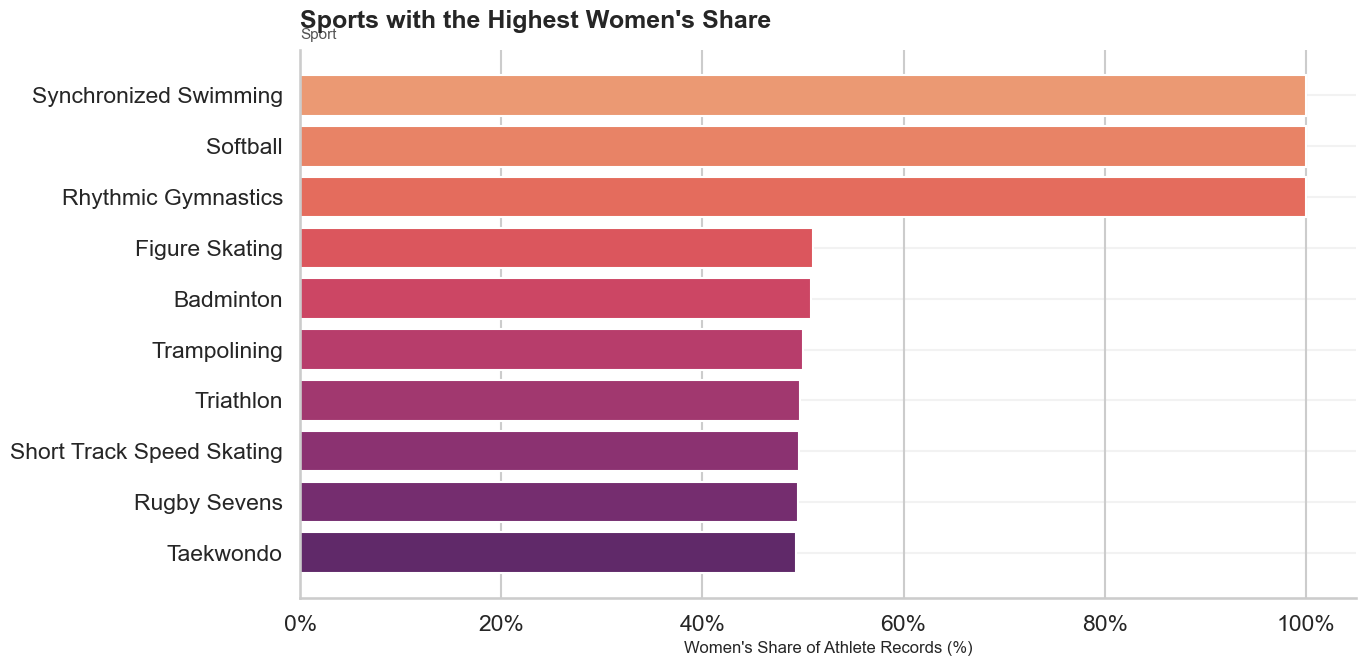

In [253]:
female_balanced = sport_gender.sort_values("women_share", ascending=False).head(10).reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
colors = sns.color_palette("flare", len(female_balanced))
ax.barh(female_balanced["sport"], female_balanced["women_share"], color=colors)
ax.invert_yaxis()
polish_axes(
    ax,
    "Sports with the Highest Women's Share",
    "Sport",
    "Women's Share of Athlete Records (%)",
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()


## 4 Sports Distribution

### 4.1 Most common sports

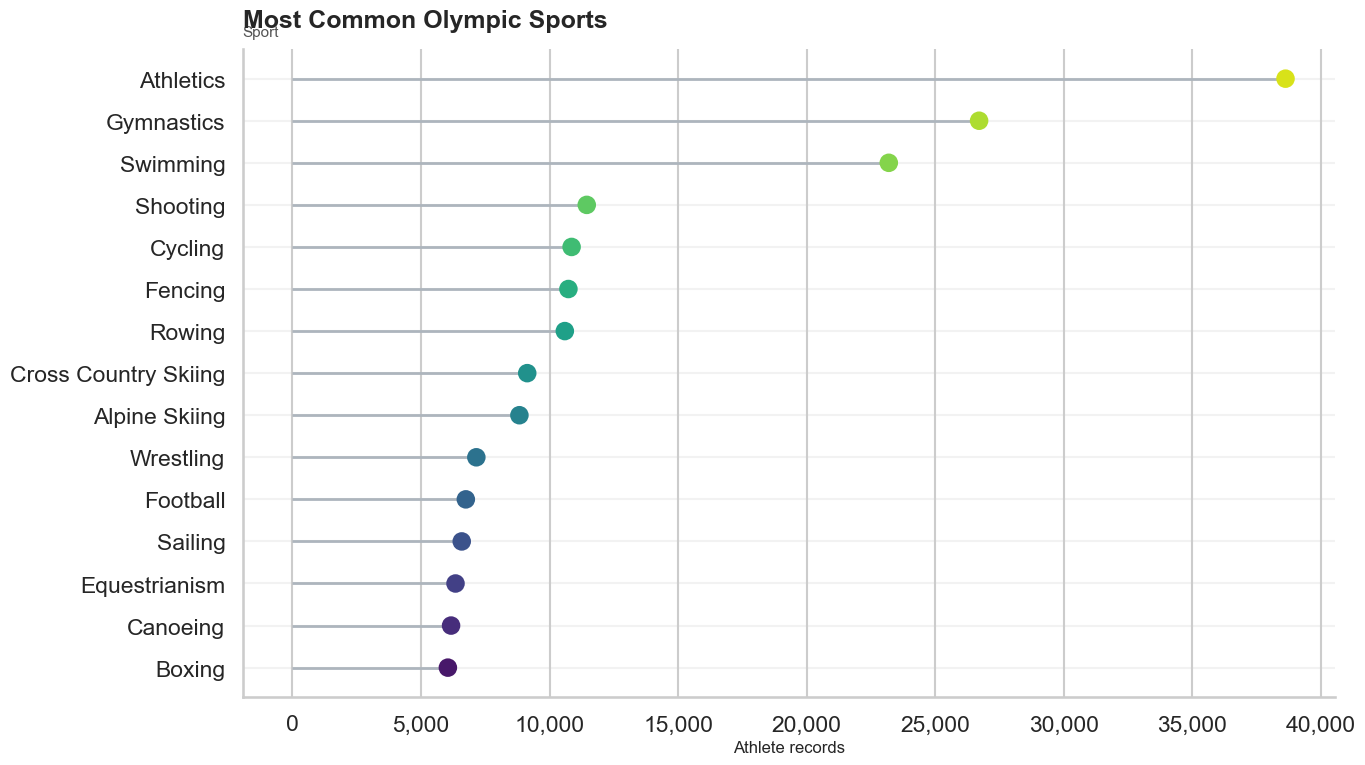

In [254]:
top_sports = olympics["sport"].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(14, 8))
ax.hlines(y=top_sports.index, xmin=0, xmax=top_sports.values, color="#adb5bd", linewidth=2)
ax.scatter(top_sports.values, top_sports.index, s=140, c=sns.color_palette("viridis", len(top_sports)), zorder=3)
polish_axes(
    ax,
    "Most Common Olympic Sports",
    "Sport",
    "Athlete records",
)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()


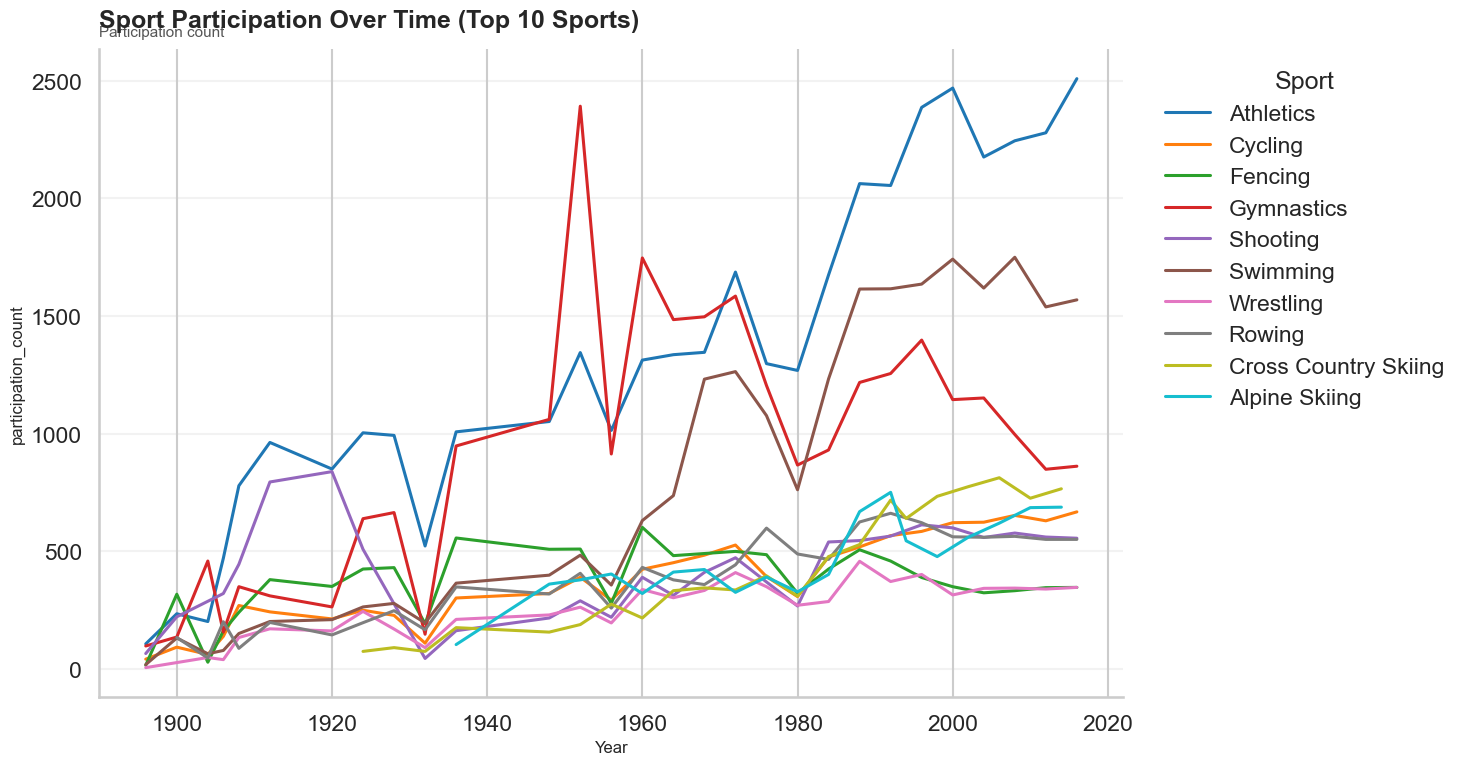

In [255]:
sport_year = (
    olympics.groupby(["year", "sport"])
    .size()
    .reset_index(name="participation_count")
)

# Top sports only
top_sports = (
    sport_year.groupby("sport")["participation_count"]
    .sum()
    .nlargest(10)
    .index
)

sport_year_top = sport_year[sport_year["sport"].isin(top_sports)]

plt.figure(figsize=(15, 8))
ax = sns.lineplot(
    data=sport_year_top,
    x="year",
    y="participation_count",
    hue="sport",
    palette="tab10",
    linewidth=2.2,
)
polish_axes(
    ax,
    "Sport Participation Over Time (Top 10 Sports)",
    "Participation count",
    "Year",
)
plt.legend(title="Sport", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [256]:
year_summary = (
    olympics.groupby("year")
    .agg(
        sports=("sport", "nunique"),
        events=("event", "nunique"),
        regions=("country", "nunique")
    )
    .reset_index()
)

year_summary.head()

,year,sports,events,regions
0,1896,9,43,12
1,1900,20,90,31
2,1904,18,95,14
3,1906,13,74,20
4,1908,24,109,22


### 4.2 Female representation by sport

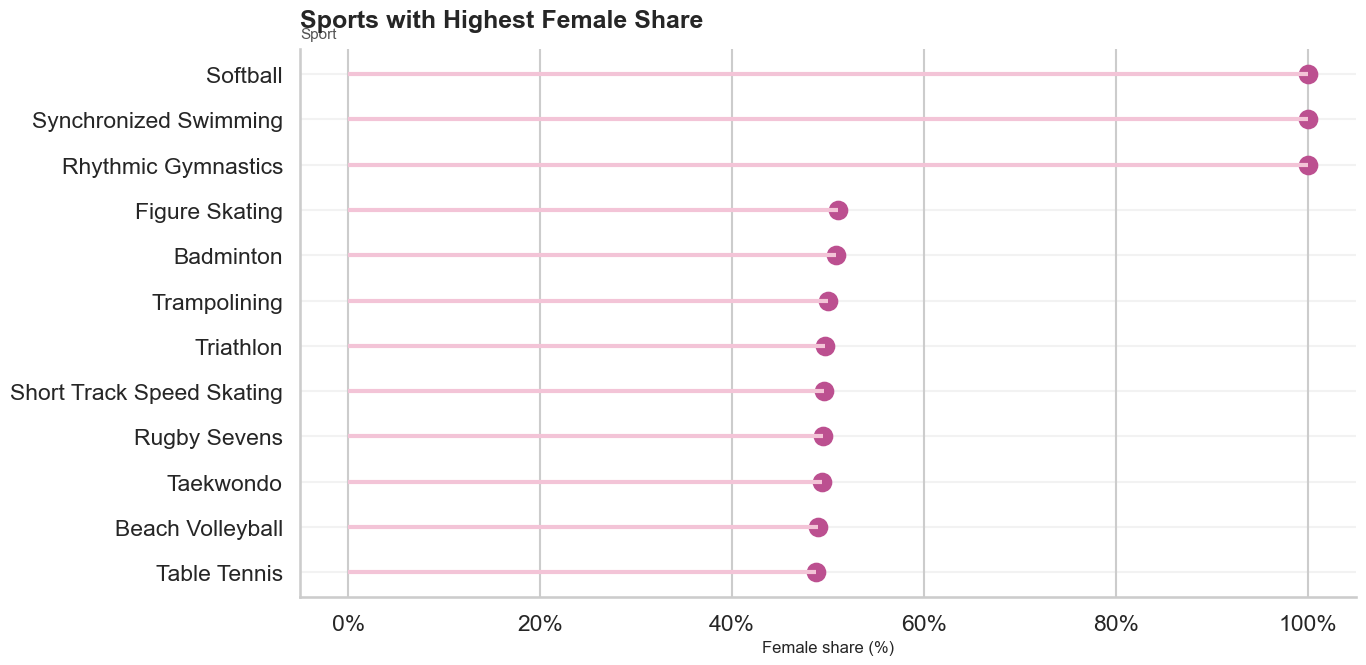

In [257]:
sport_gender = olympics.groupby(["sport","gender"]).size().unstack(fill_value=0)

sport_gender["total"] = sport_gender.sum(axis=1)
sport_gender["female_share"] = 100 * sport_gender["F"] / sport_gender["total"]

sport_gender = sport_gender[sport_gender["total"] > 100]

top_female = sport_gender.sort_values("female_share", ascending=False).head(12).sort_values("female_share")

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(top_female["female_share"], top_female.index, s=160, color="#bc5090")
for y, val in enumerate(top_female["female_share"]):
    ax.hlines(y=top_female.index[y], xmin=0, xmax=val, color="#f3c4d7", linewidth=3)
polish_axes(
    ax,
    "Sports with Highest Female Share",
    "Sport",
    "Female share (%)",
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()


## 5 Countries & Medals

### 5.1 Countries with largest delegations

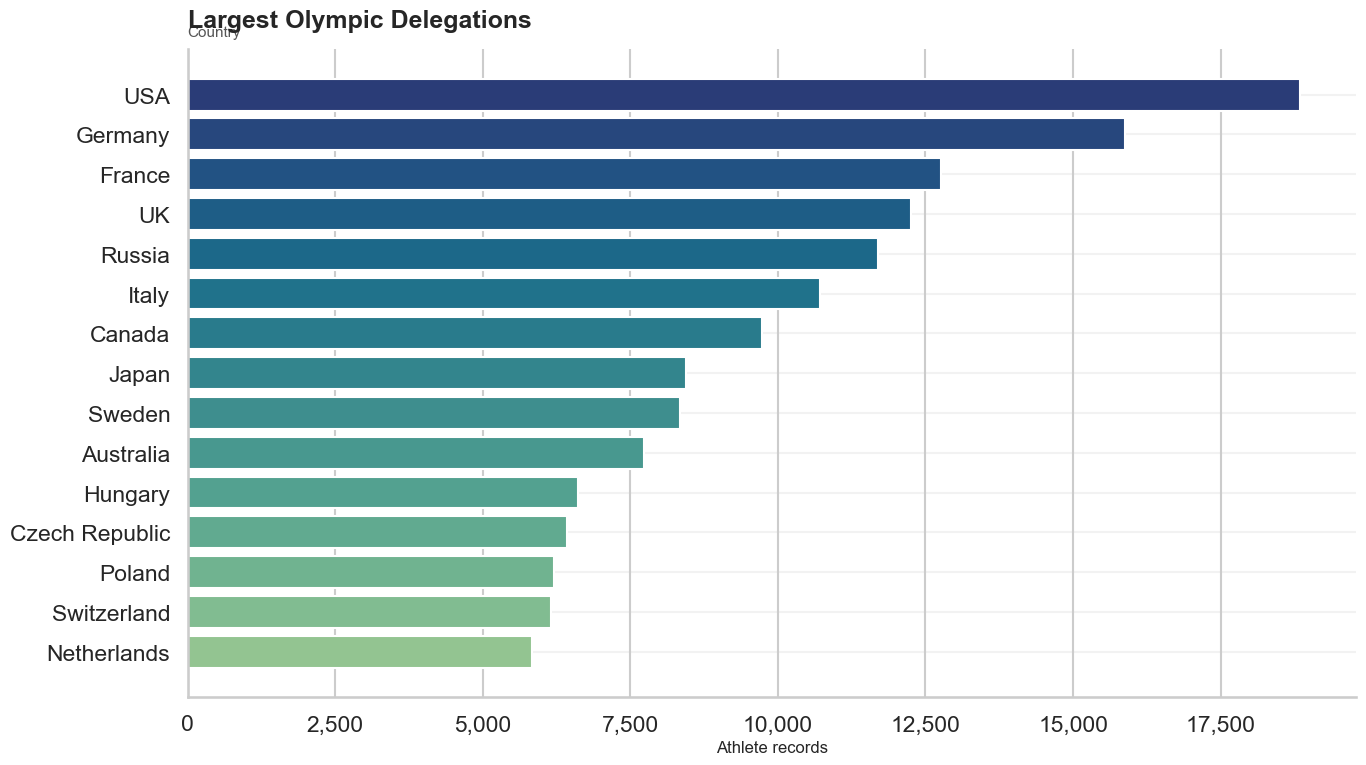

In [258]:
top_countries = olympics["country"].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(top_countries.index, top_countries.values, color=sns.color_palette("crest", len(top_countries)))
polish_axes(
    ax,
    "Largest Olympic Delegations",
    "Country",
    "Athlete records",
)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()


In [259]:
region_year = (
    olympics.groupby(["year", "country"])
    .size()
    .reset_index(name="count")
)

print("Countries with the most athlete records:")
olympics["country"].value_counts().head(10)

Countries with the most athlete records:


country
USA          18853
Germany      15883
France       12758
UK           12256
Russia       11692
Italy        10715
Canada        9734
Japan         8444
Sweden        8339
Australia     7724
Name: count, dtype: int64

### 5.2 Countries with most medals

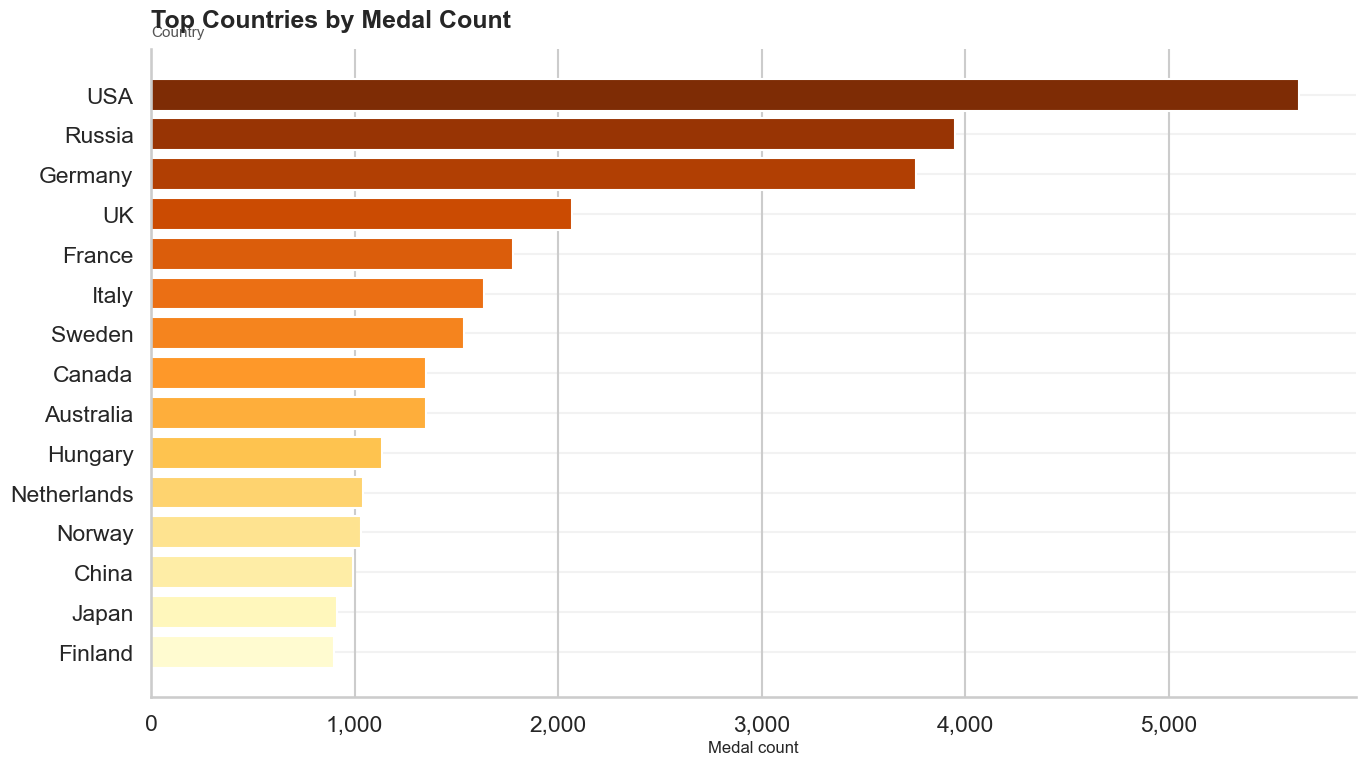

In [260]:
medals = olympics[olympics["medal"].notna()]

medal_counts = medals.groupby("country").size().sort_values(ascending=False).head(15).sort_values()

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(medal_counts.index, medal_counts.values, color=sns.color_palette("YlOrBr", len(medal_counts)))
polish_axes(
    ax,
    "Top Countries by Medal Count",
    "Country",
    "Medal count",
)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()


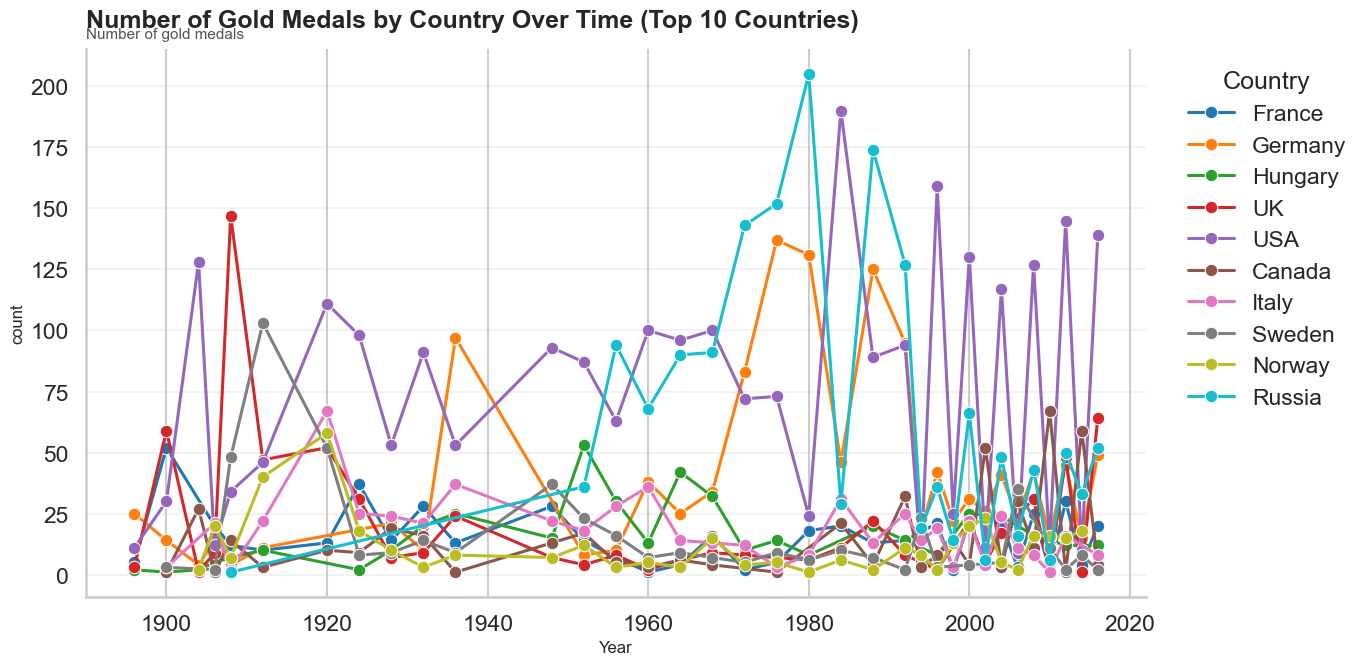

In [261]:
gold_medals = olympics[olympics["medal"] == "Gold"]

gold_year_region = (
    gold_medals
    .groupby(["year", "country"])
    .size()
    .reset_index(name="count")
)

top_regions = (
    gold_year_region
    .groupby("country")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

gold_top = gold_year_region[gold_year_region["country"].isin(top_regions)]

plt.figure(figsize=(14, 7))
ax = sns.lineplot(
    data=gold_top,
    x="year",
    y="count",
    hue="country",
    palette="tab10",
    linewidth=2.2,
    marker="o",
)
polish_axes(
    ax,
    "Number of Gold Medals by Country Over Time (Top 10 Countries)",
    "Number of gold medals",
    "Year",
)
plt.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [262]:
fig = px.area(
    gold_top,
    x="year",
    y="count",
    color="country",
    line_group="country",
    title="Gold Medals by Country Over Time (Top 10 Countries)",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Number of gold medals",
    legend_title_text="Country",
)

fig.show()


### 5.3 Medal inequality

### 5.4 Countries with many participants but no medals

In [263]:
all_countries = set(olympics["country"].dropna().unique())
medal_countries = set(olympics.loc[olympics["medal"].notna(), "country"].dropna().unique())

never_medaled = sorted(all_countries - medal_countries)

never_medaled_df = (
    olympics[olympics["country"].isin(never_medaled)]
    .groupby("country")
    .agg(
        participations=("id", "count"),
        sports=("sport", "nunique")
    )
    .sort_values("participations", ascending=False)
    .reset_index()
)

print(f"Number of countries that never won a medal: {len(never_medaled_df)}")
never_medaled_df.head(10)

Number of countries that never won a medal: 69


,country,participations,sports
0,Angola,267,11
1,El Salvador,218,14
2,Honduras,189,13
3,San Marino,181,14
4,Andorra,169,12
5,Boliva,152,16
6,Bosnia and Herzegovina,134,15
7,Antigua,133,6
8,Nicaragua,129,10
9,Madagascar,119,9


C:\Users\salve\AppData\Local\Temp\ipykernel_2504\2513163752.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


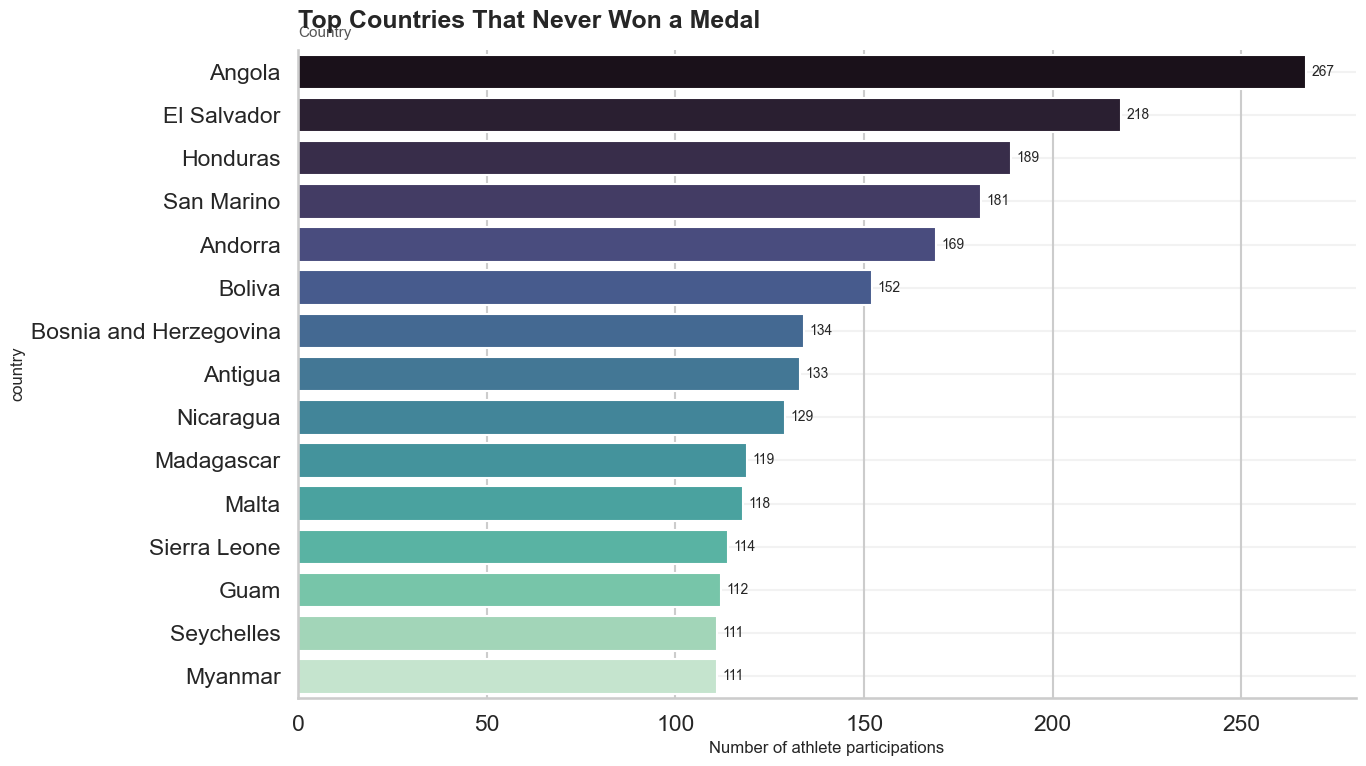

In [264]:
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=never_medaled_df.head(15),
    x="participations",
    y="country",
    palette="mako",
)
polish_axes(
    ax,
    "Top Countries That Never Won a Medal",
    "Country",
    "Number of athlete participations",
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=4, fontsize=10)
plt.tight_layout()
plt.show()


## 6 Economic Inequality

### 6.1 GDP vs medals

In [265]:
medals_df = olympics[
    olympics["medal"].notna() &
    olympics["gdp_per_capita"].notna() &
    olympics["population"].notna()
].copy()

country_medals = (
    medals_df.groupby(["country", "gdp_per_capita", "population"])
    .size()
    .reset_index(name="medal_count")
)

fig = px.scatter(
    country_medals,
    x="gdp_per_capita",
    y="medal_count",
    size="population",
    color="medal_count",
    hover_name="country",
    title="GDP per Capita vs Medal Count",
    labels={
        "gdp_per_capita": "GDP per Capita (USD)",
        "medal_count": "Total Medal Count",
        "population": "Population"
    },
    size_max=30,
    template="plotly_white",
    color_continuous_scale="Viridis"
)

fig.update_traces(marker=dict(line=dict(width=0.5, color="white"), opacity=0.8))
fig.show()


In [266]:
medals_df = olympics[
    olympics["medal"].notna() &
    olympics["gdp_per_capita"].notna() &
    olympics["population"].notna()
].copy()

country_medals = (
    medals_df
    .groupby(["year", "country", "gdp_per_capita", "population"])
    .size()
    .reset_index(name="medal_count")
)

fig = px.scatter(
    country_medals,
    x="gdp_per_capita",
    y="medal_count",
    size="population",
    color="medal_count",
    animation_frame="year",
    hover_name="country",
    title="GDP per Capita vs Medal Count Over Time",
    labels={
        "gdp_per_capita": "GDP per Capita (USD)",
        "medal_count": "Total Medal Count",
        "population": "Population",
        "year": "Year"
    },
    size_max=60,
    template="plotly_white",
    color_continuous_scale="Plasma"
)

fig.update_traces(marker=dict(line=dict(width=0.4, color="white"), opacity=0.75))
fig.show()


### 6.2 Population vs medals

## 7 Athlete Characteristics

### 7.1 Age distribution

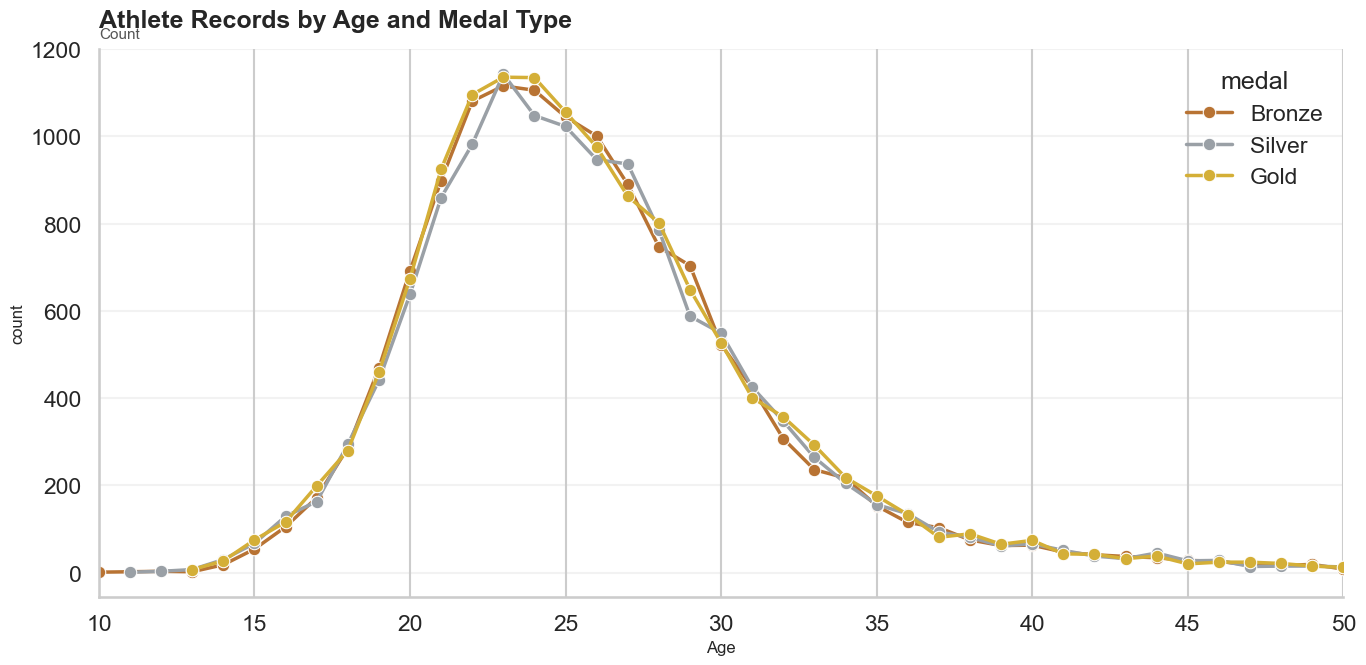

In [267]:
medals_age = olympics.dropna(subset=["age"]).copy()

age_medal = (
    medals_age.groupby(["age", "medal"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(14, 7))
ax = sns.lineplot(
    data=age_medal,
    x="age",
    y="count",
    hue="medal",
    palette=PALETTES["medals"],
    linewidth=2.5,
    marker="o",
)
polish_axes(
    ax,
    "Athlete Records by Age and Medal Type",
    "Count",
    "Age",
)
ax.set_xlim(10, 50)
plt.tight_layout()
plt.show()


### 7.2 Age and medal performance

C:\Users\salve\AppData\Local\Temp\ipykernel_2504\860747274.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


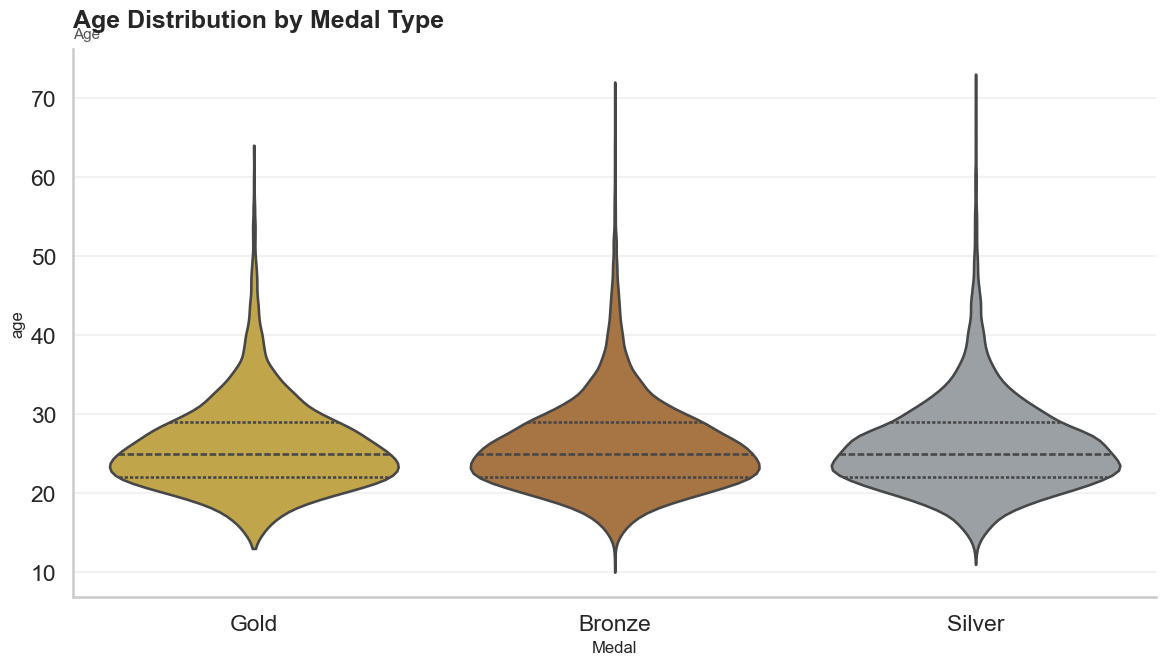

In [268]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.violinplot(
    data=olympics.dropna(subset=["age","medal"]),
    x="medal",
    y="age",
    palette=PALETTES["medals"],
    inner="quartile",
    cut=0,
    ax=ax,
)
polish_axes(
    ax,
    "Age Distribution by Medal Type",
    "Age",
    "Medal",
)
plt.tight_layout()
plt.show()


## 8 Conflicts & Geopolitics

### 8.1 Participation during conflicts

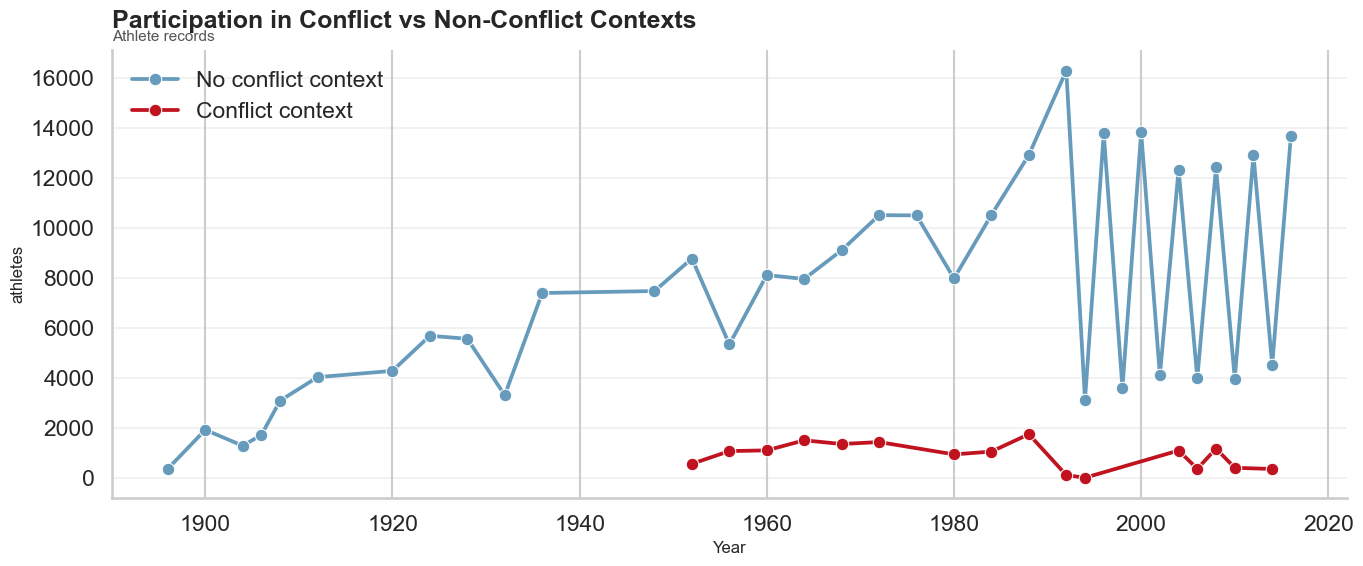

In [269]:
conflict = olympics.copy()
conflict["conflict"] = conflict["conflict_name"].notna()

conflict_counts = conflict.groupby(["year","conflict"]).size().reset_index(name="athletes")
conflict_counts["context"] = conflict_counts["conflict"].map({True: "Conflict context", False: "No conflict context"})

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=conflict_counts,
    x="year",
    y="athletes",
    hue="context",
    palette={"Conflict context": PALETTES["conflict"][True], "No conflict context": PALETTES["conflict"][False]},
    linewidth=2.7,
    marker="o",
    ax=ax,
)
polish_axes(
    ax,
    "Participation in Conflict vs Non-Conflict Contexts",
    "Athlete records",
    "Year",
)
ax.legend(title="")
plt.tight_layout()
plt.show()
